In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('/Users/gautam/Desktop/MinneMUDAC2025/sorted_Training.csv', low_memory=False)

In [27]:
df['Completion Date'] = pd.to_datetime(df['Completion Date'])
df_filtered = df.dropna(subset=['Completion Date', 'Match Length']).copy()
df_filtered['Time Gap'] = df_filtered.groupby('Match ID 18Char')['Completion Date'].diff().dt.days
df_gaps = df_filtered.dropna(subset=['Time Gap'])

There seems to be a low positive correlation total time gap and the match length (this is not unexpected)

Correlation between time gap and Match Length:
               Time Gap  Match Length
Time Gap      1.000000      0.303351
Match Length  0.303351      1.000000


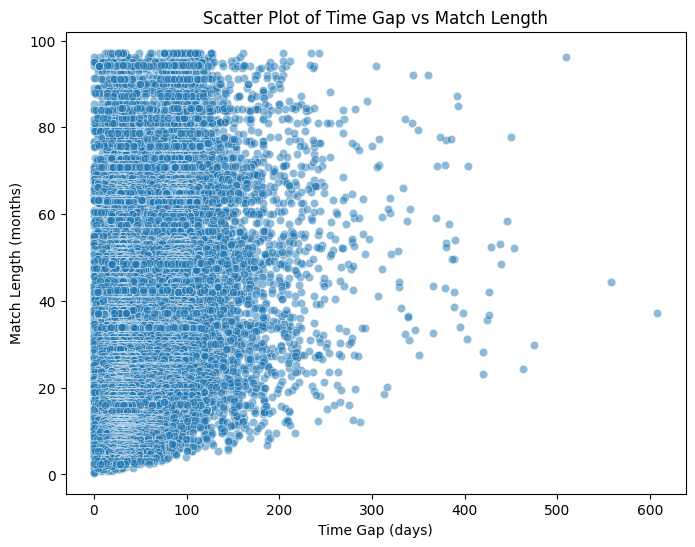

In [11]:
# correlation between time gap and match length
correlation = df_gaps[['Time Gap', 'Match Length']].corr()
print("Correlation between time gap and Match Length:\n", correlation)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_gaps, x='Time Gap', y='Match Length', alpha=0.5)
plt.xlabel('Time Gap (days)')
plt.ylabel('Match Length (months)')
plt.title('Scatter Plot of Time Gap vs Match Length')
plt.show()

Medium positive correlation between time gap and match length. As the time gap increases, the match length also increases.

In [6]:
# Compute average time gap per Match ID
df_avg_time_gap = df_gaps.groupby('Match ID 18Char').agg(
    avg_time_gap=('Time Gap', 'mean'),
    Match_Length=('Match Length', 'first')
).dropna()

# Compute correlation between average time gap and match length
avg_time_gap_correlation = df_avg_time_gap.corr()
print("Correlation between Average Time Gap and Match Length:\n", avg_time_gap_correlation)

Correlation between Average Time Gap and Match Length:
               avg_time_gap  Match_Length
avg_time_gap      1.000000      0.551664
Match_Length      0.551664      1.000000


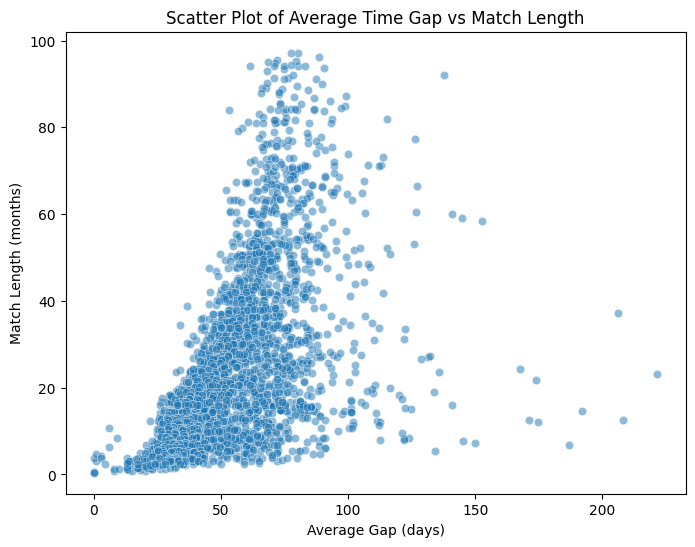

In [7]:
# Plot average time gap vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_avg_time_gap, x='avg_time_gap', y='Match_Length', alpha=0.5)
plt.xlabel('Average Gap (days)')
plt.ylabel('Match Length (months)')
plt.title('Scatter Plot of Average Time Gap vs Match Length')
plt.show()

Low negative correlation between frequency and match length

In [8]:
# Compute frequency as the inverse of average time gap
df_avg_time_gap['Frequency'] = 1 / df_avg_time_gap['avg_time_gap']

# correlation between frequency and match length
freq_correlation = df_avg_time_gap[['Frequency', 'Match_Length']].corr()
print("Correlation between Frequency and Match Length:\n", freq_correlation)

Correlation between Frequency and Match Length:
               Frequency  Match_Length
Frequency      1.000000     -0.225412
Match_Length  -0.225412      1.000000


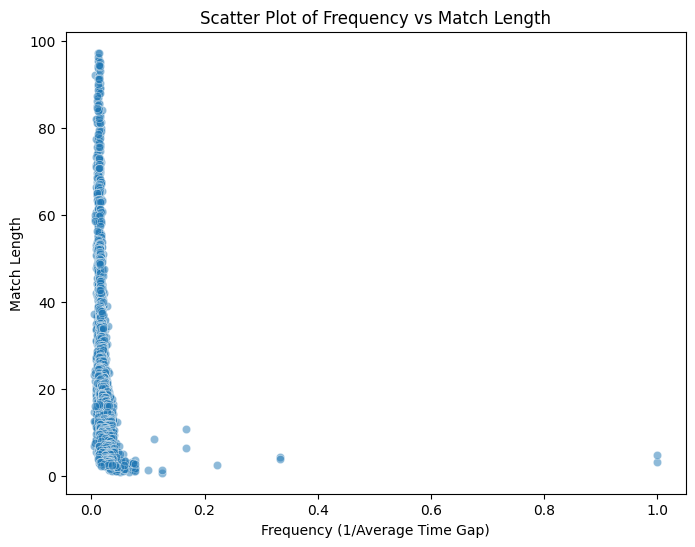

In [9]:
# Visualization for frequency vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_avg_time_gap, x='Frequency', y='Match_Length', alpha=0.5)
plt.xlabel('Frequency (1/Average Time Gap)')
plt.ylabel('Match Length')
plt.title('Scatter Plot of Frequency vs Match Length')
plt.show()

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

In [42]:
# Sentiment Analysis of Match Support Contact Notes
excluded_words = {'answer', 'b_first_name', 'bb', 'bbbs', 'big', 'bs','l_first_name','little','mec', 'asked', 'question'}
df_filtered['Filtered Notes'] = df_filtered['Match Support Contact Notes'].astype(str).apply(
    lambda text: ' '.join([word for word in text.split() if word.lower() not in excluded_words])
)
df_filtered['Sentiment'] = df_filtered['Filtered Notes'].apply(lambda text: TextBlob(text).sentiment.polarity)

# Compute correlation between sentiment and match length
sentiment_correlation = df_filtered[['Sentiment', 'Match Length']].corr()
print("Correlation between Sentiment and Match Length:\n", sentiment_correlation)

# Extract top keywords using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = vectorizer.fit_transform(df_filtered['Filtered Notes'])
keywords = [word for word in vectorizer.get_feature_names_out() if word not in excluded_words]
print("Top Keywords in Match Contact Notes:", keywords)

# Compute correlation between keyword frequencies and match length
keyword_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
keyword_df = keyword_df.loc[:, ~keyword_df.columns.isin(excluded_words)]
keyword_df['Match Length'] = df_filtered['Match Length'].values
keyword_correlation = keyword_df.corr()['Match Length'].drop('Match Length')
print("Correlation between Keywords and Match Length:\n", keyword_correlation)

# Early vs Late Stage Analysis
def label_stage(group):
    n = len(group)
    early_end = n // 4
    late_start = 3 * (n // 4)
    group['Stage'] = ['Early'] * early_end + ['Middle'] * (n - early_end - (n - late_start)) + ['Late'] * (n - late_start)
    return group

df_staged = df_filtered.groupby('Match ID 18Char').apply(label_stage)

# Compute sentiment difference between early and late stages
stage_sentiment = df_staged[df_staged['Stage'].isin(['Early', 'Late'])].groupby('Stage')['Sentiment'].mean()
print("Sentiment in Early vs Late Stages:\n", stage_sentiment)

Correlation between Sentiment and Match Length:
               Sentiment  Match Length
Sentiment      1.000000      0.083488
Match Length   0.083488      1.000000
Top Keywords in Match Contact Notes: ['activities', 'check', 'child', 'concerns', 'going', 'know', 'lb', 'like', 'match', 'month', 'relationship', 'safety', 'said', 'school', 'support', 'time', 'year']
Correlation between Keywords and Match Length:
 activities      0.076478
check           0.119056
child           0.013108
concerns       -0.017948
going           0.062096
know            0.045540
lb              0.004141
like            0.048297
match           0.067288
month           0.073442
relationship    0.033292
safety         -0.022818
said           -0.026800
school          0.017133
support         0.096540
time            0.056259
year            0.005520
Name: Match Length, dtype: float64
Sentiment in Early vs Late Stages:
 Stage
Early    0.199252
Late     0.159414
Name: Sentiment, dtype: float64


/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_23060/4034650993.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_staged = df_filtered.groupby('Match ID 18Char').apply(label_stage)


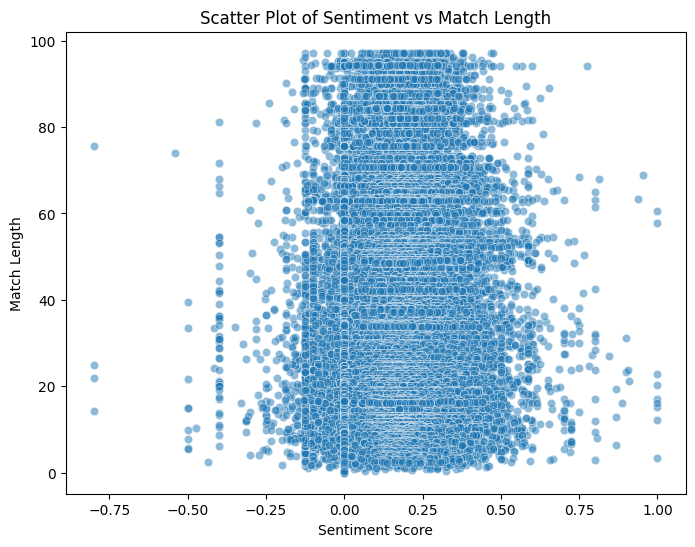

In [39]:
# Visualization for sentiment vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filtered, x='Sentiment', y='Match Length', alpha=0.5)
plt.xlabel('Sentiment Score')
plt.ylabel('Match Length')
plt.title('Scatter Plot of Sentiment vs Match Length')
plt.show()

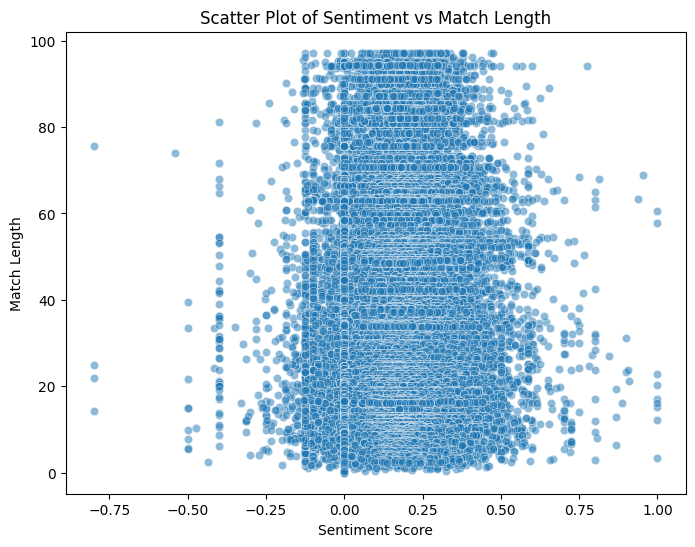

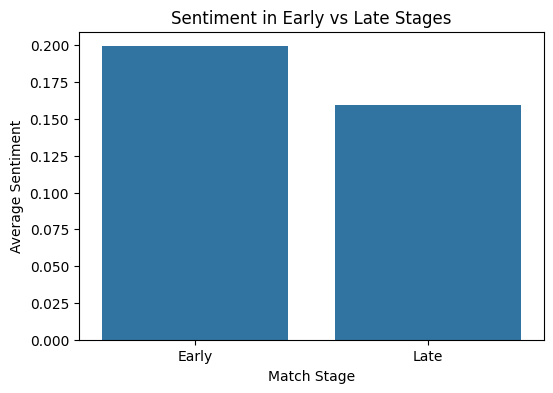

In [40]:
# Visualization for sentiment vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filtered, x='Sentiment', y='Match Length', alpha=0.5)
plt.xlabel('Sentiment Score')
plt.ylabel('Match Length')
plt.title('Scatter Plot of Sentiment vs Match Length')
plt.show()

# Visualization for sentiment in early vs late stages
plt.figure(figsize=(6, 4))
sns.barplot(x=stage_sentiment.index, y=stage_sentiment.values)
plt.xlabel('Match Stage')
plt.ylabel('Average Sentiment')
plt.title('Sentiment in Early vs Late Stages')
plt.show()